# Breakpoints

For `human-in-the-loop`, we often want to see our graph outputs as its running.

We laid the foundations for this with streaming.


## Goals

Now, let's talk about the motivations for `human-in-the-loop`:

1) `Approval` - We can interrupt our agent, surface state to a user, and allow the user to accept an action.

2) `Debbuging` - We can rewind the graph to reproduce or avoid issues

3) `Editing` - You can modify the state


LangGraph offers several ways to get or update agent state to support various `human-in-the-loop` workflows.

First, we'll introduce `breakpoints`, which provide a simple way to stop the graph at specific steps.

We'll show how this enables user `approval`. 

In [1]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("ANTHROPIC_API_KEY")

## Breakpoints for human approval

let's reconsider the simple agent that we worked with in Module 1.

Let's assume that are concerned about tool use: we want to approve the agent to use any of its tools.

All we need to do is simply compile the graph with `interrupt_before=["tools"]` where `tools` is our tools node.

This means that the execution will be interrupted before the node `tools`, which executes the tool call.

In [2]:
from langchain_anthropic import ChatAnthropic

def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

# This will be a tool
def add(a: int, b: int) -> int:
    """Adds a and b

    Args:
        a: first int
        b: second int    
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Divide a and b
    
    Args:
        a: first int
        b: second int
    """
    return a / b


tools = [multiply, add, divide]
llm = ChatAnthropic(model="claude-haiku-4-5")
llm_with_tools = llm.bind_tools(tools)

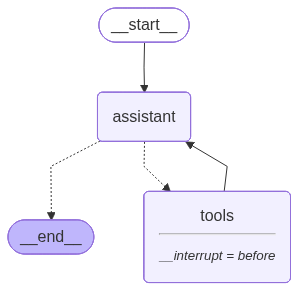

In [3]:
from IPython.display import Image, display
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import MessagesState
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import tools_condition, ToolNode

from langchain_core.messages import AIMessage, HumanMessage, SystemMessage

# System Message
sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs.")

# Node
def assistant(state: MessagesState):
    return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

# graph
builder = StateGraph(MessagesState)

# Define nodes: these do the work
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# Define edges: these determine the control flow
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    tools_condition
)
builder.add_edge("tools", "assistant")

memory = MemorySaver()
graph = builder.compile(interrupt_before=["tools"], checkpointer=memory)

# show
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [4]:
# input
initial_input = {"messages": HumanMessage(content="Multiple 2 and 3")}

# Thread
thread = {"configurable": {"thread_id": "1"}}

# Run the graph until the first interruption
for event in graph.stream(initial_input, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Multiple 2 and 3
================================== Ai Message ==================================

[{'id': 'toolu_01GXEAv8BaaAkZ8hGLE9WaX7', 'caller': {'type': 'direct'}, 'input': {'a': 2, 'b': 3}, 'name': 'multiply', 'type': 'tool_use'}]
Tool Calls:
  multiply (toolu_01GXEAv8BaaAkZ8hGLE9WaX7)
 Call ID: toolu_01GXEAv8BaaAkZ8hGLE9WaX7
  Args:
    a: 2
    b: 3


In [5]:
state = graph.get_state(thread)
state.next

('tools',)

In [6]:
for event in graph.stream(None, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================== Ai Message ==================================

[{'id': 'toolu_01GXEAv8BaaAkZ8hGLE9WaX7', 'caller': {'type': 'direct'}, 'input': {'a': 2, 'b': 3}, 'name': 'multiply', 'type': 'tool_use'}]
Tool Calls:
  multiply (toolu_01GXEAv8BaaAkZ8hGLE9WaX7)
 Call ID: toolu_01GXEAv8BaaAkZ8hGLE9WaX7
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6
================================== Ai Message ==================================

2 multiplied by 3 equals **6**.


Now, lets bring these together with a specific user approval step that accepts user input.

In [7]:
# input
initial_input = {"messages": HumanMessage(content="Multiple 2 & 3")}

# Thread
thread = {"configurable": {"thread_id": "3"}}

# Run the graph until the first interruption
for event in graph.stream(initial_input, thread, stream_mode="values"):
    event["messages"][-1].pretty_print()


# Get user feedback
user_approval = input("Do you want to call the tool? (yes/no): ")

# Check approval
if user_approval.lower() == "yes":
    # If approved, continue the graph execution
    for event in graph.stream(None, thread, stream_mode="values"):
        event['messages'][-1].pretty_print()

else:
    print("Operation cancelled by user.")

================================ Human Message =================================

Multiple 2 & 3
================================== Ai Message ==================================

[{'id': 'toolu_01HBhVG5WJEqo6Ey66UBFrva', 'caller': {'type': 'direct'}, 'input': {'a': 2, 'b': 3}, 'name': 'multiply', 'type': 'tool_use'}]
Tool Calls:
  multiply (toolu_01HBhVG5WJEqo6Ey66UBFrva)
 Call ID: toolu_01HBhVG5WJEqo6Ey66UBFrva
  Args:
    a: 2
    b: 3
================================== Ai Message ==================================

[{'id': 'toolu_01HBhVG5WJEqo6Ey66UBFrva', 'caller': {'type': 'direct'}, 'input': {'a': 2, 'b': 3}, 'name': 'multiply', 'type': 'tool_use'}]
Tool Calls:
  multiply (toolu_01HBhVG5WJEqo6Ey66UBFrva)
 Call ID: toolu_01HBhVG5WJEqo6Ey66UBFrva
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6
================================== Ai Message ==================================

The result of multiplying 2 and 

We saw how breakpoints support user approval, but don't yet know how to modify our graph state once our graph is interrupted.

Let's see how to directly edit the graph state and insert human feedback.

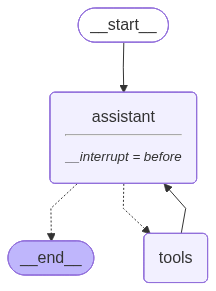

In [8]:
# let compile the graph with different interrupt before parameter
graph = builder.compile(interrupt_before=["assistant"], checkpointer=memory)

# Show the graph
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

We can see the graph is interrupted before the chat model responds.

In [9]:
# Input
initial_input = {"messages": "Multiply 2 & 3"}

# thread
thread = {"configurable": {"thread_id": "4"}}

# Run the graph until the first interruption
for event in graph.stream(initial_input, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Multiply 2 & 3


In [10]:
state = graph.get_state(thread)
state

StateSnapshot(values={'messages': [HumanMessage(content='Multiply 2 & 3', additional_kwargs={}, response_metadata={}, id='74f4c69d-f025-4239-b773-909ff29888e7')]}, next=('assistant',), config={'configurable': {'thread_id': '4', 'checkpoint_ns': '', 'checkpoint_id': '1f17ce90-0532-6970-8000-73dba3e9c01b'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-07-11T05:25:59.987026+00:00', parent_config={'configurable': {'thread_id': '4', 'checkpoint_ns': '', 'checkpoint_id': '1f17ce90-0530-6d78-bfff-d95918d94f83'}}, tasks=(PregelTask(id='5160dce1-34f0-261b-18d7-fc3810a0fc94', name='assistant', path=('__pregel_pull', 'assistant'), error=None, interrupts=(), state=None, result=None),), interrupts=())

Now, we can directly apply a state update

Remember, updates to the `messages` key will use the `add_messages` reducer:

- if we want to over-write the existing message, we can supply the message `id`.
- if we simply want to append to our list of messages, then we can pass a message without an `id` specified, as shown below.

In [11]:
graph.update_state(
    thread,
    {"messages": [HumanMessage(content="No, actually multiply 2 & 2!")]}
)

{'configurable': {'thread_id': '4',
  'checkpoint_ns': '',
  'checkpoint_id': '1f17cea8-30a5-62e8-8001-af1004244876'}}

In [12]:
new_state = graph.get_state(thread).values
for m in new_state['messages']:
    m.pretty_print()

================================ Human Message =================================

Multiply 2 & 3
================================ Human Message =================================

No, actually multiply 2 & 2!


In [13]:
for event in graph.stream(None, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

No, actually multiply 2 & 2!
================================== Ai Message ==================================

[{'id': 'toolu_01SZ47JQjvgUUw8gVggAsVLS', 'caller': {'type': 'direct'}, 'input': {'a': 2, 'b': 2}, 'name': 'multiply', 'type': 'tool_use'}]
Tool Calls:
  multiply (toolu_01SZ47JQjvgUUw8gVggAsVLS)
 Call ID: toolu_01SZ47JQjvgUUw8gVggAsVLS
  Args:
    a: 2
    b: 2
================================= Tool Message =================================
Name: multiply

4


Now, we're back at the `assistant`, which has our `breakpoint`.

We can again pass `None` to proceed.

In [14]:
for event in graph.stream(None, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================= Tool Message =================================
Name: multiply

4
================================== Ai Message ==================================

The result of 2 × 2 is **4**.


## Awaiting user input

So, it's clear that we can edit our agent state after a breakpoint.

Now, what if we want to allow for human feedback to perform this state update?

We'll add a node that server as a placeholder for human feedback within our agent.

This `human_feedback` node allow the user to add feedback directly to state. 

We set up a checkpointer to save the state of the graph up until this node.


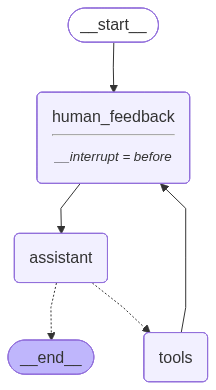

In [15]:
# system message
sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs.")


# no-op node that should be interrupted on
def human_feedback(state: MessagesState):
    pass

# Assistant node
def assistant(state: MessagesState):
    return {"messages": [llm_with_tools.invoke([sys_msg] + state['messages'])]}


# graph
builder = StateGraph(MessagesState)

# define nodes
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))
builder.add_node("human_feedback", human_feedback)

# Define edges
builder.add_edge(START, "human_feedback")
builder.add_edge("human_feedback", "assistant")
builder.add_conditional_edges("assistant", tools_condition)
builder.add_edge("tools", "human_feedback")

memory = MemorySaver()

graph = builder.compile(interrupt_before=["human_feedback"], checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))


In [16]:
# Input
initial_input = {"messages": "Multiply 2 and 3"}

# thread
thread = {"configurable": {"thread_id": "5"}}

# Run the graph until the first interruption
for event in graph.stream(initial_input, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

# get user input
user_input = input("Tell me how you want to update the state: ")


# we now update the state
graph.update_state(thread, {"messages": user_input}, as_node="human_feedback")

# continue the graph execution
for event in graph.stream(None, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================ Human Message =================================

no, multiply 4 and 5
================================== Ai Message ==================================

[{'id': 'toolu_014Pt6jXh4mZ1t9zLJ3k4bEy', 'caller': {'type': 'direct'}, 'input': {'a': 4, 'b': 5}, 'name': 'multiply', 'type': 'tool_use'}]
Tool Calls:
  multiply (toolu_014Pt6jXh4mZ1t9zLJ3k4bEy)
 Call ID: toolu_014Pt6jXh4mZ1t9zLJ3k4bEy
  Args:
    a: 4
    b: 5
================================= Tool Message =================================
Name: multiply

20


In [17]:
# Continue the graph execution
for event in graph.stream(None, thread, stream_mode="values"):
    event["messages"][-1].pretty_print()

================================= Tool Message =================================
Name: multiply

20
================================== Ai Message ==================================

The result of multiplying 4 and 5 is **20**.
